In [1]:
import numpy as np

# 1. Load the files (allow_pickle=True is strictly required for mixed object arrays)
events_data = np.load('events.npy', allow_pickle=True)
regions_data = np.load('regions.npy', allow_pickle=True)

print(f"Loaded {len(events_data)} events and {len(regions_data)} regions.")

# 2. Let's look at a single flood to verify
first_flood_id = events_data[0, 0]
first_flood_vector = events_data[0, 1]

print(f"\nFirst Event: {first_flood_id}")
print(f"Vector Dimensions: {first_flood_vector.shape}")

Loaded 1525 events and 1520 regions.

First Event: name=Paraguay: Floods - Feb 1990
Vector Dimensions: (512,)


In [2]:
# Extract just the text IDs into a 1D list
event_ids = events_data[:, 0]

# Stack the vectors into a perfect 2D matrix (Rows = Disasters, Columns = 512 dimensions)
event_matrix = np.stack(events_data[:, 1])

print(f"\nReady for Scikit-Learn!")
print(f"Matrix Shape: {event_matrix.shape}") 
# This will output exactly (Number of Events, 512)


Ready for Scikit-Learn!
Matrix Shape: (1525, 512)


In [3]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Choose your target event
target_event = "name=Paraguay: Floods - Feb 1990"

# Find which row index this event is in
target_idx = np.where(event_ids == target_event)[0][0]

# 2. Calculate similarities between your target and ALL 1,525 events
# We reshape the target vector to (1, -1) because sklearn expects a 2D array
similarities = cosine_similarity(event_matrix[target_idx].reshape(1, -1), event_matrix)[0]

# 3. Get the indices of the top 6 highest scores (the 1st one will be the event itself = 1.0)
# argsort() sorts lowest to highest, so we slice [::-1] to reverse it
top_indices = np.argsort(similarities)[::-1][1:6] 

print(f"Top 5 Disasters most similar to {target_event}:\n")
for i in top_indices:
    print(f"Similarity Score: {similarities[i]:.4f} | Event: {event_ids[i]}")

Top 5 Disasters most similar to name=Paraguay: Floods - Feb 1990:

Similarity Score: 0.7691 | Event: name=Paraguay: Floods - Mar 1995
Similarity Score: 0.7520 | Event: FL-1997-000299-PRY
Similarity Score: 0.7315 | Event: FL-2002-000296-PRY
Similarity Score: 0.7285 | Event: name=Niger: Floods - Aug 1994
Similarity Score: 0.7086 | Event: FL-2009-000226-PRY


Compressing 512 dimensions to 2D for visualization...


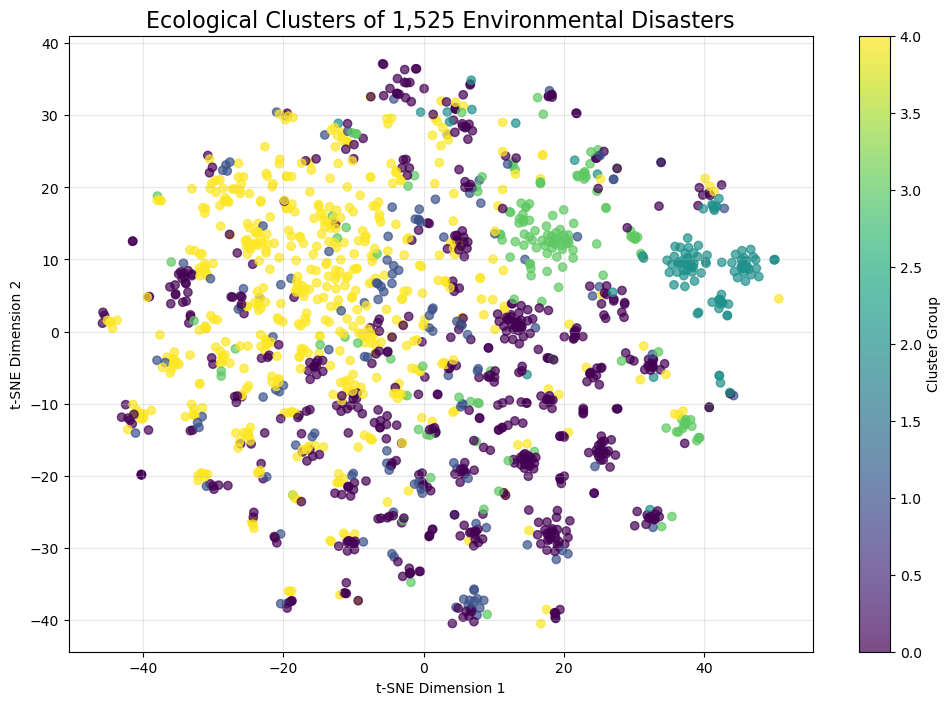

In [4]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Compressing 512 dimensions to 2D for visualization...")

# 1. Compress vectors to 2D using t-SNE (this takes a few seconds)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
matrix_2d = tsne.fit_transform(event_matrix)

# 2. Find clusters using K-Means (Let's group them into 5 distinct "families")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(event_matrix)

# 3. Plot the results!
plt.figure(figsize=(12, 8))
scatter = plt.scatter(matrix_2d[:, 0], matrix_2d[:, 1], c=clusters, cmap='viridis', alpha=0.7)

plt.title("Ecological Clusters of 1,525 Environmental Disasters", fontsize=16)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="Cluster Group")
plt.grid(True, alpha=0.3)
plt.show()

Here compare regions

In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the pure country profiles
regions_data = np.load('pure_regions.npy', allow_pickle=True)
region_names = regions_data[:, 0]
region_matrix = np.stack(regions_data[:, 1])

# 2. Find Paraguay
target = "Paraguay"

try:
    target_idx = np.where(region_names == target)[0][0]
    
    # 3. Calculate similarities across the whole world
    similarities = cosine_similarity(region_matrix[target_idx].reshape(1, -1), region_matrix)[0]
    
    # 4. Get the top 10 (excluding the first one which is Paraguay itself)
    top_indices = np.argsort(similarities)[::-1][1:50]
    
    print(f"🌍 Top 10 Ecological Matches for {target}:")
    print("-" * 50)
    for i in top_indices:
        print(f"Similarity: {similarities[i]:.4f} | Country: {region_names[i]}")

except IndexError:
    print(f"Could not find '{target}'. Check your spelling or try: {region_names[:5]}")

🌍 Top 10 Ecological Matches for Paraguay:
--------------------------------------------------
Similarity: 0.4370 | Country: Nicaragua
Similarity: 0.4292 | Country: Brazil
Similarity: 0.4127 | Country: Timor-Leste
Similarity: 0.4001 | Country: Republic of Congo
Similarity: 0.3983 | Country: Angola
Similarity: 0.3981 | Country: Togo
Similarity: 0.3970 | Country: East Timor
Similarity: 0.3934 | Country: Burundi
Similarity: 0.3897 | Country: Guyana
Similarity: 0.3798 | Country: Bolivia Plurinational State of
Similarity: 0.3798 | Country: Russian Federation
Similarity: 0.3779 | Country: Niger
Similarity: 0.3774 | Country: Central African Republic
Similarity: 0.3749 | Country: Australia
Similarity: 0.3735 | Country: South Africa
Similarity: 0.3697 | Country: China
Similarity: 0.3652 | Country: Dominica
Similarity: 0.3630 | Country: Liberia
Similarity: 0.3588 | Country: Peru
Similarity: 0.3565 | Country: Papua New Guinea
Similarity: 0.3560 | Country: Namibia
Similarity: 0.3548 | Country: Yemen

In [8]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the profiles
regions_data = np.load('pure_regions.npy', allow_pickle=True)
region_names = regions_data[:, 0]
region_matrix = np.stack(regions_data[:, 1])

# 2. Get the indices
try:
    idx_p = np.where(region_names == 'Paraguay')[0][0]
    idx_s = np.where(region_names == 'Serbia')[0][0]

    # Calculate similarity
    sim_score = cosine_similarity(region_matrix[idx_p].reshape(1, -1), 
                                  region_matrix[idx_s].reshape(1, -1))[0][0]

    print(f"📊 Cosine Similarity:")
    print(f"Paraguay vs. Serbia = {sim_score:.4f}")

except IndexError:
    print("Could not find one of the countries. Check exact spelling in your data!")

📊 Cosine Similarity:
Paraguay vs. Serbia = 0.2697


In [10]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the profiles
regions_data = np.load('pure_regions.npy', allow_pickle=True)
region_names = regions_data[:, 0]
region_matrix = np.stack(regions_data[:, 1])

# 2. Find Serbia
target = "Serbia"

try:
    target_idx = np.where(region_names == target)[0][0]
    
    # Calculate similarities
    similarities = cosine_similarity(region_matrix[target_idx].reshape(1, -1), region_matrix)[0]
    
    # Get Top 10
    top_indices = np.argsort(similarities)[::-1][1:50]
    
    print(f"🌍 Top 10 Ecological Matches for {target}:")
    print("-" * 50)
    for i in top_indices:
        print(f"Similarity: {similarities[i]:.4f} | Country: {region_names[i]}")

except IndexError:
    # If "Serbia" isn't the exact name, print names to check spelling
    print(f"Could not find '{target}'. Check spelling: {region_names[:10]}")

🌍 Top 10 Ecological Matches for Serbia:
--------------------------------------------------
Similarity: 0.3817 | Country: the Republic of North Macedonia
Similarity: 0.3516 | Country: Montenegro
Similarity: 0.3484 | Country: Georgia
Similarity: 0.3453 | Country: Bulgaria
Similarity: 0.3444 | Country: Romania
Similarity: 0.3413 | Country: Hungary
Similarity: 0.3398 | Country: Belarus
Similarity: 0.3345 | Country: Czech Republic
Similarity: 0.3306 | Country: Northern Ireland
Similarity: 0.3276 | Country: Bosnia
Similarity: 0.3215 | Country: Côte d'Ivoire
Similarity: 0.3204 | Country: China
Similarity: 0.3196 | Country: Slovakia
Similarity: 0.3171 | Country: Iran Islamic Republic of
Similarity: 0.3140 | Country: Tonga
Similarity: 0.3121 | Country: Poland
Similarity: 0.3102 | Country: Gabon
Similarity: 0.3037 | Country: Chad
Similarity: 0.3003 | Country: Morocco
Similarity: 0.2992 | Country: Czechia
Similarity: 0.2991 | Country: United Kingdom of Great Britain
Similarity: 0.2958 | Country: 

In [11]:
import numpy as np

# Load files with allow_pickle=True since they contain object/string IDs
events = np.load('events.npy', allow_pickle=True)
regions = np.load('regions.npy', allow_pickle=True)

def inspect_npy(name, data):
    print(f"\n{'='*20} {name.upper()} {'='*20}")
    print(f"Shape: {data.shape}")
    print(f"Dtype: {data.dtype}")
    
    # Check if it's a 2D array (ID + Vector) or just a dictionary/array
    if len(data.shape) > 1:
        print(f"Columns: {data.shape[1]}")
        print("\nFirst 3 Rows (Preview):")
        for i in range(min(3, len(data))):
            # We slice the vector so it doesn't flood the screen
            id_val = data[i, 0]
            vector_preview = data[i, 1][:5] if isinstance(data[i, 1], (np.ndarray, list)) else "No Vector"
            print(f"Row {i} | ID: {id_val} | Vector[:5]: {vector_preview}...")
    else:
        print("\nData looks like a 1D array or dictionary object.")
        print(f"First 3 elements: {data[:3]}")

inspect_npy("events", events)
inspect_npy("regions", regions)


==================== EVENTS ====================
Shape: (1525, 2)
Dtype: object
Columns: 2

First 3 Rows (Preview):
Row 0 | ID: name=Paraguay: Floods - Feb 1990 | Vector[:5]: [ 0.55469352 -0.11144215 -0.07778326  0.05527509  0.0657683 ]...
Row 1 | ID: FL-2021-000213-STP | Vector[:5]: [ 0.3630425  -0.34722126  0.14793111 -0.15886447 -0.13069803]...
Row 2 | ID: FL-2025-000038-BOL | Vector[:5]: [ 0.54808521 -0.2412958  -0.07166266  0.06752126  0.0892491 ]...

==================== REGIONS ====================
Shape: (1520, 2)
Dtype: object
Columns: 2

First 3 Rows (Preview):
Row 0 | ID: 1 | Vector[:5]: [ 0.2263296  -0.15191787  0.04853309 -0.16689815 -0.0441076 ]...
Row 1 | ID: 1985-06-01-ARG-Flood | Vector[:5]: [ 0.20337397  0.1793038  -0.13320683 -0.23418045  0.08386374]...
Row 2 | ID: 1985-11-01T00:00:00+00:00 | Vector[:5]: [ 0.20337397  0.1793038  -0.13320683 -0.23418045  0.08386374]...
